# Extractive Text Summarization berbasis Min-Hash

Studi kasus: Jurnal **Perkembangan dan Peran OPAC pada Aplikasi CIP (Cerah Informasi Pustaka) untuk Temu Kembali Informasi di Perpustakaan Universitas Tridinanti Palembang** (Betari Ayu Elsadantia, 2023).

## Aturan implementasi (dari dosen)
1. **Input adalah 1 dokumen utuh** (raw text), bukan D1/D2/D3 manual.
2. **RegEx memotong bab**: hanya isi `PENDAHULUAN` s/d akhir `HASIL PENELITIAN DAN PEMBAHASAN`. Abstrak, Kesimpulan, Daftar Pustaka harus terbuang otomatis.
3. **Paragraf = sub-dokumen**: deteksi paragraf via karakter enter (`\n\n`). Paragraf 1 = D1, paragraf 2 = D2, dst.
4. **Scoring & summarization**: bangun shingle set tiap paragraf, hitung Min-Hash signature, ukur Jaccard similarity terhadap query, lalu ranking dan ekstrak kalimat terbaik tiap paragraf.

## Pipeline notebook
1. **Ekstraksi PDF → raw text** (pdfplumber)
2. **RegEx** memotong bab (PENDAHULUAN s/d HASIL PENELITIAN DAN PEMBAHASAN)
3. **Split paragraf** (`\n\n`) → daftar sub-dokumen D1, D2, …
4. **Preprocessing** (case folding → cleaning → tokenizing → stopword removal → stemming)
5. **Pembangunan Shingle Set** (k-shingle dari token hasil preprocessing)
6. **Min-Hash Signature Matrix** (fungsi hash acak universal)
7. **Estimasi Jaccard Similarity** dokumen vs query via Min-Hash
8. **Ranking Min-Hash** berdasar Jaccard similarity
9. **Perbandingan ranking** (urutan dokumen hasil Min-Hash)
10. **Summarization** (kalimat skor Min-Hash tertinggi tiap paragraf)


## 0. Install dependencies (sekali saja)

In [1]:
# Pasang library yang dibutuhkan (jalankan sekali di environment baru / Colab)
!pip install -q pdfplumber PySastrawi numpy pandas

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import math
import re
import hashlib
import random
import itertools
from collections import Counter

import numpy as np
import pandas as pd
import pdfplumber
import matplotlib.pyplot as plt

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

stopword_factory = StopWordRemoverFactory()
stopword_remover = stopword_factory.create_stop_word_remover()

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

print('Import dan konfigurasi selesai. Teks tabel tidak dipotong.')


Import dan konfigurasi selesai. Teks tabel tidak dipotong.


## LANGKAH 1 — Ekstraksi `Jurnal.pdf` menjadi raw text

Tantangan: pdfplumber memecah teks per baris (line-wrap), bukan per paragraf. Untuk
menghormati aturan dosen ("paragraf dipisah karakter enter"), kita memanfaatkan posisi
horizontal `x0` tiap baris:

* Baris **rata kiri** (`x0 ≈ 104.9`) → lanjutan paragraf yang sama.
* Baris **terindentasi** (`x0 ≈ 133.3`) → awal paragraf baru → sisipkan `\n\n`.
* Header bab (PENDAHULUAN, METODE, dll.) berdiri sendiri di kolom kiri → diberi `\n\n` sendiri.

Hasilnya satu string raw text yang strukturnya "berantakan tapi paragraf jelas".

In [3]:
PATH_PDF = 'Jurnal.pdf'

def ekstrak_pdf_jadi_raw_text(path_pdf: str) -> str:
    """Ekstrak PDF jurnal jadi 1 string raw text dengan paragraf dipisah \\n\\n.

    Strategi:
      - Posisi x0 untuk mendeteksi indent (= awal paragraf baru).
      - Pola UPPERCASE pendek untuk header bab (PENDAHULUAN/METODE/dll.).
      - Font 'Arial-BoldMT' untuk sub-judul Title Case (Perpustakaan, OPAC,
        Sistem Temu Kembali Informasi, dll.) yang dibuang sepenuhnya.
        Pembedanya dengan kutipan judul: sub-judul muncul SETELAH paragraf
        yang berakhir dengan tanda baca akhir kalimat (./?/!).
      - Page-footer & running-header juga disaring.
    """
    BATAS_INDENT = 125
    bagian_paragraf: list[str] = []
    buffer = ''

    def flush():
        nonlocal buffer
        if buffer.strip():
            bagian_paragraf.append(buffer.strip())
        buffer = ''

    pola_header_bab = re.compile(r'^[A-Z][A-Z\s]{3,40}$')
    pola_sampah = re.compile(
        r'^(?:\d+\s+Jurnal Multidisipliner|'
        r'Perkembangan Dan Peran Opac Pada Aplikasi|'
        r'Informasi Pustaka\) Untuk Temu Kembali|'
        r'Perpustakaan Universitas Tridinanti Palembang\s*$|'
        r'Betari Ayu\s*$|Elsadantia\s*$)',
        flags=re.IGNORECASE,
    )

    # State: apakah baris sebelumnya berakhir dengan tanda baca akhir kalimat?
    # True berarti kita berada di "boundary" antar-paragraf -> baris bold di
    # posisi ini sangat mungkin sub-judul.
    prev_end_with_period = True   # awal dokumen dianggap boundary
    skip_streak = False           # apakah baris bold sebelumnya juga sub-judul

    with pdfplumber.open(path_pdf) as pdf:
        for hal in pdf.pages:
            for ln in hal.extract_text_lines():
                teks_baris = ln['text'].strip()
                if not teks_baris or pola_sampah.search(teks_baris):
                    continue

                chars = ln.get('chars', [])
                font_pertama = chars[0].get('fontname', '') if chars else ''
                line_bold = 'Arial-BoldMT' in font_pertama

                terindentasi = ln['x0'] > BATAS_INDENT
                header_bab = bool(pola_header_bab.match(teks_baris))

                # Sub-judul Title Case: bold + posisi boundary + bukan UPPERCASE bab
                # Atau: bold + lanjutan dari sub-judul multi-baris sebelumnya
                sub_judul_title_case = line_bold and not header_bab and (
                    prev_end_with_period or skip_streak
                )

                if sub_judul_title_case:
                    flush()                 # tutup paragraf sebelumnya
                    skip_streak = True       # next bold line juga = continuation
                    # state prev_end_with_period dipertahankan (masih di boundary)
                    continue

                # Update state untuk baris berikutnya
                skip_streak = False
                prev_end_with_period = bool(re.search(r'[.!?]\s*$', teks_baris))

                if terindentasi or header_bab:
                    flush()
                    buffer = teks_baris
                    if header_bab:
                        flush()
                else:
                    buffer = (buffer + ' ' + teks_baris).strip()
    flush()

    return '\n\n'.join(bagian_paragraf)


teks_jurnal = ekstrak_pdf_jadi_raw_text(PATH_PDF)
print(f'Total karakter raw text: {len(teks_jurnal):,}')
print('=' * 78)
print('CUPLIKAN 800 KARAKTER PERTAMA:')
print('=' * 78)
print(teks_jurnal[:800])

Total karakter raw text: 22,811
CUPLIKAN 800 KARAKTER PERTAMA:
Prodi Ilmu Perpustakaan, Fakultas Adab dan Humaniora, UIN Raden Fatah Palembang

Email: betariayu2511@gmail.com ARTICLE HISTORY Abstrak Received: Penelitian ini membahas mengenai Perkembangan dan Peran OPAC Pada Aplikasi CIP (Cerah 12 Oktober 2023 Informasi Pustaka) untuk temu kembali informasi yang ada di Perpustakaan Tridinanti Revised Palembang. Di dalam artikel ini akan disampaikan mengenai Perkembangan dan Peran OPAC 14 Oktober 2023 Pada Aplikasi CIP (Cerah Informasi Pustaka) dalam meningkatkan layanan Perpustakaan Accepted: Tridinanti Palembang, serta efektivitas Perkembangan dan Peran OPAC Pada CIP (Cerah 23 Oktober 2023 Informasi Pustaka) sebagai sistem temu kembali informasi yang ada di Perpustakaan tersebut.

30 Oktober 2023 memberikan suatu kemudahan bagi pemustaka serta memberi


## LANGKAH 2 — RegEx memotong bab

Hanya isi mulai dari `PENDAHULUAN` sampai sebelum `KESIMPULAN` yang akan kita pakai.
Bagian Abstrak (di atas PENDAHULUAN) dan Kesimpulan + Daftar Pustaka (setelah Hasil)
akan otomatis terbuang.

In [4]:
# ---- REGEX UTAMA: tangkap teks mulai dari kata kunci 'PENDAHULUAN'
# sampai sebelum kata kunci 'KESIMPULAN' (penanda akhir bab Hasil & Pembahasan).
# Flag re.DOTALL membuat titik (.) ikut cocok dengan karakter newline,
# sehingga grup (.*?) bisa melahap lintas paragraf. Penggunaan *? (lazy)
# memastikan match berhenti di kemunculan KESIMPULAN yang PERTAMA.
pola_bab = re.compile(
    r'PENDAHULUAN\s*\n(.*?)\n\s*KESIMPULAN',
    flags=re.DOTALL | re.IGNORECASE,
)

match_bab = pola_bab.search(teks_jurnal)   # eksekusi pencarian RegEx pada teks mentah
if not match_bab:
    raise ValueError('Bab PENDAHULUAN..KESIMPULAN tidak ditemukan.')

isi_bab = match_bab.group(1).strip()        # group(1) = isi di antara dua penanda

print(f'Karakter sebelum RegEx: {len(teks_jurnal):,}')
print(f'Karakter setelah RegEx: {len(isi_bab):,}  (Abstrak + Kesimpulan + Pustaka terbuang)')
print('=' * 78)
print('CUPLIKAN 400 KARAKTER PERTAMA HASIL POTONG:')
print('=' * 78)
print(isi_bab[:400], '...')
print('=' * 78)
print('CUPLIKAN 400 KARAKTER TERAKHIR HASIL POTONG:')
print('=' * 78)
print('...', isi_bab[-400:])

Karakter sebelum RegEx: 22,811
Karakter setelah RegEx: 15,844  (Abstrak + Kesimpulan + Pustaka terbuang)
CUPLIKAN 400 KARAKTER PERTAMA HASIL POTONG:
Dunia saat ini sangatlah bergantung terhadap yang namanya teknologi. Di zaman yang serba modern ini manusia diharuskan untuk memahami perkembangan teknologi yang terjadi, salah satunya ialah teknologi informasi. Perkembangan teknologi ini banyak dilakukan di sebuah perusahaan maupun lembaga informasi lainnya. Awal dari perkembangan teknologi yang sederhana ini perusahaan-perusaan dan lembaga-lemba ...
CUPLIKAN 400 KARAKTER TERAKHIR HASIL POTONG:
... kasi CIP (Cerah Informasi Pustaka) ini sangat efektif dan memiliki banyak peran bagi pemustaka dan pustakawan yaitu untuk mempermudah dalam temu kembali suatu informasi, mempermudah dalam mengklasifikasi bahan pustaka.

Kendala dalam Penelusuran OPAC dengan menggunakan aplikasi CIP (Cerah Informasi Pustaka) yaitu jaringan nya kadang eror serta menu-menu item yang pengen ditambah dan belum seles

## LANGKAH 3 — Pecah jadi paragraf (sub-dokumen)

Setiap paragraf dipisah `\n\n`, jadi cukup `.split('\n\n')`. Sub-judul pendek
(mis. `OPAC`, `Perkembangan OPAC`) yang tidak memuat kalimat valid kita buang dengan
ambang panjang minimum 30 karakter.

In [5]:
# ---- PEMISAHAN PARAGRAF: gunakan split('\n\n') sesuai instruksi dosen.
# Setiap elemen hasil split kita anggap sebagai 1 sub-dokumen (D1, D2, ...).
paragraf_kasar = isi_bab.split('\n\n')

# Filter:
#  - Buang paragraf < 30 karakter (sub-judul pendek seperti "OPAC")
#  - Buang baris UPPERCASE-only (sisa header bab seperti "HASIL PENELITIAN DAN PEMBAHASAN")
pola_uppercase_only = re.compile(r'^[A-Z\s]+$')

daftar_paragraf = [
    p.strip() for p in paragraf_kasar
    if len(p.strip()) >= 30 and not pola_uppercase_only.match(p.strip())
]

# Bangun dict dokumen & label sesuai pola notebook STKI_TFIDF_VSM_Final
dokumen = {f'D{i+1}': p for i, p in enumerate(daftar_paragraf)}
label_dokumen = {f'D{i+1}': f'Paragraf {i+1}' for i in range(len(daftar_paragraf))}

print(f'Total paragraf terdeteksi (sub-dokumen): {len(daftar_paragraf)}')
print('=' * 78)
df_korpus = pd.DataFrame({
    'Dokumen': list(dokumen.keys()),
    'Bagian Jurnal': [label_dokumen[d] for d in dokumen.keys()],
    'Teks Asli': list(dokumen.values()),
})
display(df_korpus)

Total paragraf terdeteksi (sub-dokumen): 26


,Dokumen,Bagian Jurnal,Teks Asli
0,D1,Paragraf 1,"Dunia saat ini sangatlah bergantung terhadap yang namanya teknologi. Di zaman yang serba modern ini manusia diharuskan untuk memahami perkembangan teknologi yang terjadi, salah satunya ialah teknologi informasi. Perkembangan teknologi ini banyak dilakukan di sebuah perusahaan maupun lembaga informasi lainnya. Awal dari perkembangan teknologi yang sederhana ini perusahaan-perusaan dan lembaga-lembaga pemerintahan dan pendidikan berlomba-lomba dalam menciptakan teknologi. Begitupun didalam dunia perpustakaan, dengan adanya perkembangan teknologi, perpustakaan berusaha untuk mengembangkan eksistensinya di dalam sistem layanan informasi untuk memenuhi kebutuhan pemustaka. Khususnya dalam mengembangkan teknologi digital yang digunakan sebagai sistem temu balik informasi."
1,D2,Paragraf 2,"Perpustakaan adalah suatu ruangan bagian dari gedung atau bangunan yang berisi buku-buku koleksi, yang diatur serta disusun sedemikian rupa, sehingga mudah untuk dicari dan dipergunakan sewaktu-waktu diperlukan oleh pemakai. Perpustakaan adalah suatu ruangan bagian dari gedung atau bangunan yang berisi buku-buku koleksi, yang diatur serta disusun sedemikian rupa, sehingga mudah untuk dicari dan dipergunakan sewaktu- waktu diperlukan oleh pemakai “katalog online atau OPAC merupakan sistem katalog perpustakaan yang menggunakan komputer. Pangkalan datanya biasanya dirancang dan dibuat sendiri oleh perpustakaan dengan menggunakan perangkat lunak komersial atau buatan sendiri. Katalog ini memberikan informasi bibliografis dan letak koleksinya. Katalog biasanya dirancang untuk mempermudah pengguna sehingga tidak perlu bertanya dalam menggunakannya (user friendly)”. Dengan kata lain OPAC merupakan seperangkat sistem katalog perpustakaan berbasis online yang terpasang dan digunakan di perpustakaan sebagai alat untuk mencari koleksi yang ada di perpustakaan. Karena OPAC sebagai sistem temu balik informasi."
2,D3,Paragraf 3,"Sistem otomasi perpustakaan merupakan suatu proses pengelolaan perpustakaan dengan memanfaatkan teknologi informasi. Pemanfaatan teknologi informasi di perpustakaan bertujuan untuk meningkatkan efisiensi pekerjaan dan kualitas pelayanan pada pengguna (right information, right user dan right now), berhubungan dengan peran maupun fungsi perpustakaan sebagai kekuatan dalam pelestarian, penyebaran informasi ilmu pengetahuan serta kebudayaan yang berkembang seiring dengan kebutuhan manusia akan informasi. Perkembangan teknologi informasi telah mengubah paradigma pengelola perpustakaan yang semulanya berbasis manual sekarang sudah terotomasi. Otomasi perpustakaan merupakan suatu proses pengelolaan perpustakaan dengan memanfaatkan Teknologi Informasi (TI). Pemanfaatan sistem otomasi ini memberikan kemudahan dan kecepatan dalam proses pengolahan bahan pustaka. Selain itu, dapat memberikan kemudahan bagi pemustaka dalam melakukan penelurusan. Intinya pemanfaatan teknologi informasi di perpustakaan bertujuan untuk meningkatkan efisien pekerjaan dan kualitas pelayanan bagi pengguna. Sistem otomasi perpustakaan yang banyak digunakan oleh perpustakaan, yaitu perangkat lunak (Software) seperti Senayan Library Information Management System (SLIMS), OPAC yang digunakan yaitu berupa Aplikasi CIP (Cerah Aplikasi Pustaka) yang di buat sendiri oleh pustakawan Perpustakaan Universitas Tridinanti Palembang.Namun, perpustakaan yang sudah terotomasi juga menuntut pustakawanya harus mampu memahami isi dari perangkat lunaknya, karena akan sangat berpengaruh terhadap kinerja mereka."
3,D4,Paragraf 4,"Perpustakaan Universitas Tridinanti Palembang merupakan salah satu Perpustakaan yang telah terotomasi dengan menggunakan software berupa Aplikasi CIP (Cerah Aplikasi Pustaka) sebagai sarana temu kembali informasinya. Berdasarkan hasil observasi dan wawancara yang telah dilakukan oleh penulis di Perpustakaan Tridinanti Palembang, penelitian ini bertujuan untuk mengetahui Perkembangan dan Peran OPAC Pada Aplikasi CIP (C

## Preprocessing

Pipeline `preprocess(text)`:
1. Case folding
2. Cleaning (regex: hapus angka dan tanda baca)
3. Tokenizing
4. Stopword Removal (`StopWordRemoverFactory`)
5. Stemming (`StemmerFactory`)

In [6]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    teks_tanpa_stopword = stopword_remover.remove(' '.join(tokens))
    tokens_tanpa_stopword = teks_tanpa_stopword.split()
    tokens_stem = [stemmer.stem(token) for token in tokens_tanpa_stopword]
    return tokens_stem

hasil_preproses = {nama_dok: preprocess(teks) for nama_dok, teks in dokumen.items()}

df_preproses = pd.DataFrame({
    'Dokumen': list(hasil_preproses.keys()),
    'Bagian Jurnal': [label_dokumen[d] for d in hasil_preproses.keys()],
    'Token Hasil Preprocessing': [' '.join(v) for v in hasil_preproses.values()]
})
display(df_preproses)

,Dokumen,Bagian Jurnal,Token Hasil Preprocessing
0,D1,Paragraf 1,dunia gantung nama teknologi zaman serba modern manusia harus paham kembang teknologi salah satu teknologi informasi kembang teknologi usaha lembaga informasi kembang teknologi sederhana usaha rusa lembaga lembaga perintah didik lomba lomba cipta teknologi dalam dunia pustaka kembang teknologi pustaka usaha kembang eksistensi sistem layan informasi penuh butuh mustaka kembang teknologi digital sistem temu informasi
1,D2,Paragraf 2,pustaka ruang gedung bangun isi buku buku koleksi atur susun mudah cari waktu pakai pustaka ruang gedung bangun isi buku buku koleksi atur susun mudah cari waktu pakai katalog online opac sistem katalog pustaka komputer pangkal data rancang pustaka perangkat lunak komersial buat katalog informasi bibliografis letak koleksi katalog rancang mudah guna guna user friendly opac perangkat sistem katalog pustaka bas online pasang pustaka alat cari koleksi pustaka opac sistem temu informasi
2,D3,Paragraf 3,sistem otomasi pustaka proses kelola pustaka manfaat teknologi informasi manfaat teknologi informasi pustaka tuju tingkat efisiensi kerja kualitas layan guna right information right user right now hubung peran fungsi pustaka kuat lestari sebar informasi ilmu tahu budaya kembang iring butuh manusia informasi kembang teknologi informasi ubah paradigma kelola pustaka mula bas manual terotomasi otomasi pustaka proses kelola pustaka manfaat teknologi informasi ti manfaat sistem otomasi mudah cepat proses olah bahan pustaka mudah mustaka turus inti manfaat teknologi informasi pustaka tuju tingkat efisien kerja kualitas layan guna sistem otomasi pustaka pustaka perangkat lunak software senayan library information management system slims opac aplikasi cip cerah aplikasi pustaka pustakawan pustaka universitas tridinanti palembang pustaka terotomasi tuntut pustakawanya paham isi perangkat lunak pengaruh kerja
3,D4,Paragraf 4,pustaka universitas tridinanti palembang salah pustaka terotomasi software aplikasi cip cerah aplikasi pustaka sarana temu informasi dasar hasil observasi wawancara tulis pustaka tridinanti palembang teliti tuju kembang peran opac aplikasi cip cerah aplikasi pustaka pustaka universitas tridinanti palembang amat observasi teliti putus angkat judul kembang peran opac aplikasi cip cerah informasi mustaka temu informasi pustaka universitas tridinanti palembang
4,D5,Paragraf 5,teliti dekat deskriptif kualitatif dekat artikel kembang peran aplikasi cip cerah aplikasi pustaka pustaka tridinanti palembang sugiyono metode teliti kualitatif metode teliti landas filsafat postpositivisme teliti kondisi obyek alamiah lawan eksperimen mana teliti instrumen kunci ambil sampel sumber data purposive snowbaal teknik kumpul triangulasi gabung analisis data sifat induktif kualitatif hasil teliti kualitatif tekan makna generalisasi teliti kualitatif eksplorasi dalam fenomena sosial lingkung sosial laku jadi waktu
5,D6,Paragraf 6,teliti kualitatif teliti mengeksplor fenomena fenomena kuantifikasi sifat deskriptif proses langkah formula konsep erti erti konsep agam karakteristik barang jasa gambar gambar gaya gaya tata budaya model fisik artifak
6,D7,Paragraf 7,teliti pustaka tridinanti palembang alamat alamat jl kapten marzuki no ilir darat kec ilir darat timur kota palembang sumatera selatan teliti laksana tanggal november wib
7,D8,Paragraf 8,pustaka unit simpan koleksi bahan pustaka atur sistematis sambung maka sumber informasi definisi atas paham pustaka lembaga himpun karya koleksi koleksi tulis koleksi cetak koleksi rekam sistem susun
8,D9,Paragraf 9,lucy tedd opac sistem katalog pasang akses umum pakai telusur pangkal data katalog pustaka simpan karya infomasi lokasi sistem katalog hubung sistem sirkulasi pakai bahan pustaka cari sedia pustaka pinjam
9,D10,Paragraf 10,dasar urai simpul opac online public access catalog alat bantu telusur via katalog komputer risi cantum bibliografi akses umum temu koleksi pustaka toko buku unit informasi


In [7]:
# ============================================================
# LANGKAH B — Shingling
# ============================================================
K_SHINGLE = 2  # ukuran shingle; coba juga 1 (unigram) atau 3 (trigram)

def buat_shingle(tokens: list, k: int) -> set:
    """
    Buat himpunan k-shingle dari list token.
    Shingle direpresentasikan sebagai tuple (immutable) agar bisa masuk set.
    """
    if len(tokens) < k:
        # Jika token lebih sedikit dari k, pakai unigram
        return {tuple(tokens)}
    return {tuple(tokens[i:i+k]) for i in range(len(tokens) - k + 1)}

# Buat shingle set untuk setiap dokumen
shingle_set = {
    dok: buat_shingle(tokens, K_SHINGLE)
    for dok, tokens in hasil_preproses.items()
}

# Daftar nama dokumen (urut sesuai dokumen) untuk dipakai di langkah berikutnya
nama_dokumen = list(shingle_set.keys())

# Tampilkan ringkasan
print(f'K-Shingle: {K_SHINGLE}')
print('=' * 60)
df_shingle = pd.DataFrame({
    'Dokumen': list(shingle_set.keys()),
    'Jumlah Token': [len(hasil_preproses[d]) for d in shingle_set.keys()],
    'Jumlah Shingle Unik': [len(s) for s in shingle_set.values()],
    'Contoh Shingle (3 pertama)': [
        str(list(shingle_set[d])[:3]) for d in shingle_set.keys()
    ]
})
display(df_shingle)

# Universal shingle universe (gabungan semua shingle)
universe = sorted({s for sset in shingle_set.values() for s in sset})
shingle_index = {s: i for i, s in enumerate(universe)}  # mapping shingle → indeks integer
print(f'\nUkuran Universe Shingle: {len(universe)} shingle unik')


K-Shingle: 2


,Dokumen,Jumlah Token,Jumlah Shingle Unik,Contoh Shingle (3 pertama)
0,D1,55,49,"[('lembaga', 'informasi'), ('sistem', 'layan'), ('salah', 'satu')]"
1,D2,72,55,"[('pakai', 'katalog'), ('pustaka', 'perangkat'), ('informasi', 'bibliografis')]"
2,D3,120,96,"[('pustaka', 'perangkat'), ('otomasi', 'pustaka'), ('manfaat', 'teknologi')]"
3,D4,58,40,"[('informasi', 'dasar'), ('aplikasi', 'pustaka'), ('teliti', 'tuju')]"
4,D5,67,63,"[('generalisasi', 'teliti'), ('peran', 'aplikasi'), ('eksplorasi', 'dalam')]"
5,D6,29,28,"[('kuantifikasi', 'sifat'), ('konsep', 'erti'), ('fenomena', 'kuantifikasi')]"
6,D7,25,23,"[('palembang', 'sumatera'), ('no', 'ilir'), ('teliti', 'laksana')]"
7,D8,28,27,"[('koleksi', 'tulis'), ('atas', 'paham'), ('definisi', 'atas')]"
8,D9,30,28,"[('akses', 'umum'), ('lokasi', 'sistem'), ('pustaka', 'simpan')]"
9,D10,26,25,"[('katalog', 'komputer'), ('opac', 'online'), ('online', 'public')]"



Ukuran Universe Shingle: 885 shingle unik


In [8]:
# ============================================================
# LANGKAH C — Jaccard Similarity Eksak
# ============================================================
def jaccard_similarity(set_a: set, set_b: set) -> float:
    """Hitung Jaccard Similarity eksak antara dua himpunan."""
    if not set_a and not set_b:
        return 1.0  # keduanya kosong → identik
    irisan = len(set_a & set_b)
    gabungan = len(set_a | set_b)
    return irisan / gabungan if gabungan > 0 else 0.0

# Hitung matriks Jaccard eksak
N_DOK = len(nama_dokumen)
matrix_jaccard_eksak = pd.DataFrame(
    index=nama_dokumen, columns=nama_dokumen, dtype=float
)

for di in nama_dokumen:
    for dj in nama_dokumen:
        matrix_jaccard_eksak.loc[di, dj] = jaccard_similarity(
            shingle_set[di], shingle_set[dj]
        )

print('MATRIKS JACCARD SIMILARITY EKSAK (Ground Truth)')
print('=' * 60)
display(matrix_jaccard_eksak.round(4))

MATRIKS JACCARD SIMILARITY EKSAK (Ground Truth)


,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20,D21,D22,D23,D24,D25,D26
D1,1.0000,0.0196,0.0211,0.0114,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0182,0.0000,0.0000,0.0000,0.0000,0.0152,0.0351,0.0241,0.0154,0.0263,0.0227,0.0253,0.0000,0.0152,0.0000
D2,0.0196,1.0000,0.0134,0.0106,0.0000,0.0000,0.0000,0.0000,0.0506,0.0127,0.0481,0.0261,0.0000,0.0139,0.0163,0.0385,0.0139,0.0317,0.0225,0.0141,0.0244,0.0213,0.0235,0.0093,0.0139,0.0000
D3,0.0211,0.0134,1.0000,0.0880,0.0392,0.0000,0.0085,0.0082,0.0081,0.0000,0.0000,0.0127,0.0092,0.0000,0.0061,0.0083,0.0000,0.0095,0.0076,0.0000,0.0081,0.0074,0.0000,0.0490,0.0459,0.0370
D4,0.0114,0.0106,0.0880,1.0000,0.0842,0.0000,0.0328,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0175,0.0417,0.0133,0.0179,0.0299,0.0125,0.0141,0.1059,0.1154,0.0980
D5,0.0000,0.0000,0.0392,0.0842,1.0000,0.0111,0.0238,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0263,0.0253,0.0260
D6,0.0000,0.0000,0.0000,0.0000,0.0111,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
D7,0.0000,0.0000,0.0085,0.0328,0.0238,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0132,0.0000,0.0000
D8,0.0000,0.0000,0.0082,0.0000,0.0000,0.0000,0.0000,1.0000,0.0185,0.0000,0.0000,0.0000,0.0000,0.0085,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0149,0.0172,0.0000,0.0227,0.0000
D9,0.0000,0.0506,0.0081,0.0000,0.0000,0.0000,0.0000,0.0185,1.0000,0.0192,0.0380,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0179,0.0000,0.0000,0.0000,0.0222,0.0000
D10,0.0000,0.0127,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0192,1.0000,0.0000,0.0115,0.0541,0.0265,0.0000,0.0200,0.0238,0.0294,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [9]:
# ============================================================
# LANGKAH D — Signature Matrix Min-Hash
# ============================================================
N_HASH = 100      # jumlah fungsi hash; makin besar = makin akurat
PRIME = 4294967311  # bilangan prima besar (> ukuran universe yang mungkin)

random.seed(42)  # untuk reprodusibilitas

# Generate n pasang (a, b) acak untuk fungsi hash h(x) = (a*x + b) mod PRIME
params_hash = [
    (random.randint(1, PRIME - 1), random.randint(0, PRIME - 1))
    for _ in range(N_HASH)
]

def minhash_signature(shingle_indices: list, params: list, prime: int) -> list:
    """
    Hitung signature Min-Hash dari sebuah dokumen.

    Args:
        shingle_indices: list indeks integer dari shingle dokumen ini
        params: list (a, b) untuk tiap fungsi hash
        prime: bilangan prima untuk modulo
    Returns:
        list nilai minimum hash (signature vector)
    """
    if not shingle_indices:
        return [0] * len(params)  # dokumen kosong

    signature = []
    for a, b in params:
        # Hitung h(x) = (a*x + b) mod p untuk setiap shingle, ambil minimum
        min_hash = min((a * x + b) % prime for x in shingle_indices)
        signature.append(min_hash)
    return signature

# Konversi shingle set ke indeks integer
shingle_indices_per_dok = {
    dok: [shingle_index[s] for s in sset]
    for dok, sset in shingle_set.items()
}

# Hitung signature untuk setiap dokumen
signatures = {
    dok: minhash_signature(shingle_indices_per_dok[dok], params_hash, PRIME)
    for dok in nama_dokumen
}

# Tampilkan signature matrix (10 hash pertama)
print(f'Signature Matrix Min-Hash (N_HASH={N_HASH}, ditampilkan 10 pertama)')
print('=' * 70)
df_signature = pd.DataFrame(
    {dok: signatures[dok][:10] for dok in nama_dokumen},
    index=[f'h{i+1}' for i in range(10)]
)
display(df_signature)

Signature Matrix Min-Hash (N_HASH=100, ditampilkan 10 pertama)


,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20,D21,D22,D23,D24,D25,D26
h1,80058973,91699451,76730824,141605599,15184198,196495927,218120852,377807656,70074526,171542853,36809123,26824676,171542853,11856049,33480974,98355749,113324376,449338729,254714404,297964254,30152825,51777750,8527900,5199751,612353682,236417628
h2,11074682,12778593,5962949,49285683,9370771,89200595,391480781,85792773,7666860,202129687,16186415,127411596,198721865,17890326,47581772,45877861,200425776,544324785,44173950,167326508,90904506,90904506,56101327,163918686,52693505,351565869
h3,11860056,43897274,18155492,108531748,24730947,366509606,76214511,56768165,140568966,295299677,11580037,127978094,817830848,24450928,69639056,5284601,31026383,198627985,95380838,592170227,211498876,140848985,127698075,37321819,89085402,289004241
h4,543631,46733386,15982710,46775880,169884819,564878,570153535,15940216,154488234,185323898,92901894,62129971,169927313,31379295,15961463,123737558,77526556,46712139,77505309,816477648,185260157,92923141,139091649,108298479,108340973,847249571
h5,137311635,17499917,141832,25896480,16934958,318159130,68444254,292969441,154669720,129480031,76840817,8538395,284007919,51086169,137876594,60612650,197782453,464290455,146273157,163066283,318724089,163631242,343913778,17499917,128915072,180424368
h6,59619004,64916882,16197196,21495074,105689751,110987629,360922721,197831245,64916882,149111559,64916882,24144013,942338643,18846135,103040812,352975904,70214760,1108079058,320149852,602910996,29441891,157058376,72863699,181937611,314851974,67565821
h7,116156733,62358270,8559807,8559807,8559807,137847511,47109704,31861138,422088392,30250585,27029479,153096077,477497408,30250585,11780913,84049048,28640032,386759601,45499151,423698945,13391466,63968823,10170360,8559807,8559807,8559807
h8,2392912,87229852,27445971,94519477,10478583,10478583,414511711,548658723,111486865,78348135,44413359,36327688,271482982,145421641,3188958,381372981,406426040,95315523,195527759,195527759,95315523,61380747,171270746,95315523,11274629,95315523
h9,68014190,21828560,27052624,106502215,75711795,139766176,108975756,27052624,27052624,34750229,101278151,91107005,365470262,6433350,3959809,14130955,106502215,414129433,83409400,1221823994,280796607,160385450,375641408,106502215,27052624,60316585
h10,19320121,60271491,12732096,12732096,161938306,226891210,1906612,419399356,216065726,40971089,49446007,34383064,1933112424,56034032,23557580,66859516,66859516,60271491,60271491,60271491,60271491,60271491,8494637,92747943,45208548,791239598


In [10]:
# ============================================================
# LANGKAH E — Estimasi Jaccard Similarity dari Signature
# ============================================================
def estimasi_jaccard_minhash(sig_a: list, sig_b: list) -> float:
    """Estimasi Jaccard Similarity dari dua signature Min-Hash."""
    cocok = sum(1 for ha, hb in zip(sig_a, sig_b) if ha == hb)
    return cocok / len(sig_a)

# Bangun matriks estimasi Min-Hash
matrix_minhash = pd.DataFrame(
    index=nama_dokumen, columns=nama_dokumen, dtype=float
)

for di in nama_dokumen:
    for dj in nama_dokumen:
        matrix_minhash.loc[di, dj] = estimasi_jaccard_minhash(
            signatures[di], signatures[dj]
        )

print(f'MATRIKS ESTIMASI JACCARD (Min-Hash, N_HASH={N_HASH})')
print('=' * 60)
display(matrix_minhash.round(4))

# Hitung error estimasi
print('\nPERBANDINGAN EKSAK vs ESTIMASI (pasangan unik)')
print('=' * 75)
rows_perbandingan = []
for di, dj in itertools.combinations(nama_dokumen, 2):
    eksak = matrix_jaccard_eksak.loc[di, dj]
    estimasi = matrix_minhash.loc[di, dj]
    error = abs(eksak - estimasi)
    rows_perbandingan.append({
        'Pasangan': f'{di} – {dj}',
        'Jaccard Eksak': round(eksak, 4),
        'Estimasi Min-Hash': round(estimasi, 4),
        'Error Absolut': round(error, 4)
    })

df_perbandingan = pd.DataFrame(rows_perbandingan)
display(df_perbandingan)
print(f'\nRata-rata Error Absolut: {df_perbandingan["Error Absolut"].mean():.4f}')
print(f'Error Maksimum        : {df_perbandingan["Error Absolut"].max():.4f}')

MATRIKS ESTIMASI JACCARD (Min-Hash, N_HASH=100)


,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20,D21,D22,D23,D24,D25,D26
D1,1.00,0.01,0.03,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.02,0.04,0.04,0.03,0.02,0.03,0.02,0.00,0.02,0.00
D2,0.01,1.00,0.01,0.01,0.00,0.00,0.00,0.00,0.05,0.01,0.05,0.04,0.00,0.00,0.02,0.02,0.02,0.02,0.02,0.02,0.01,0.03,0.01,0.02,0.01,0.00
D3,0.03,0.01,1.00,0.10,0.04,0.00,0.01,0.02,0.02,0.00,0.00,0.03,0.02,0.00,0.02,0.01,0.00,0.01,0.00,0.00,0.01,0.00,0.00,0.08,0.04,0.04
D4,0.03,0.01,0.10,1.00,0.07,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.05,0.04,0.04,0.04,0.02,0.03,0.14,0.09,0.09
D5,0.00,0.00,0.04,0.07,1.00,0.03,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06,0.04,0.04
D6,0.00,0.00,0.00,0.00,0.03,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
D7,0.00,0.00,0.01,0.02,0.03,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00
D8,0.00,0.00,0.02,0.00,0.00,0.00,0.00,1.00,0.03,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.03,0.00,0.05,0.00
D9,0.00,0.05,0.02,0.00,0.00,0.00,0.00,0.03,1.00,0.01,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.00,0.00,0.00,0.04,0.00
D10,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.01,1.00,0.00,0.01,0.06,0.01,0.00,0.03,0.03,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00



PERBANDINGAN EKSAK vs ESTIMASI (pasangan unik)


,Pasangan,Jaccard Eksak,Estimasi Min-Hash,Error Absolut
0,D1 – D2,0.0196,0.01,0.0096
1,D1 – D3,0.0211,0.03,0.0089
2,D1 – D4,0.0114,0.03,0.0186
3,D1 – D5,0.0000,0.00,0.0000
4,D1 – D6,0.0000,0.00,0.0000
...,...,...,...,...
320,D23 – D25,0.0204,0.01,0.0104
321,D23 – D26,0.0000,0.00,0.0000
322,D24 – D25,0.0909,0.09,0.0009
323,D24 – D26,0.0938,0.13,0.0363



Rata-rata Error Absolut: 0.0044
Error Maksimum        : 0.0481


In [11]:
# ============================================================
# LANGKAH F — LSH Banding
# ============================================================
B = 10   # jumlah band
R = N_HASH // B  # jumlah baris per band (harus habis dibagi)

assert N_HASH % B == 0, f'N_HASH ({N_HASH}) harus habis dibagi B ({B})'

threshold_lsh = (1 / B) ** (1 / R)
print(f'Konfigurasi LSH: B={B} band, R={R} baris/band')
print(f'Threshold similaritas ≈ {threshold_lsh:.4f}')
print('(Pasangan dengan Jaccard > threshold kemungkinan besar akan terdeteksi)')
print('=' * 60)

def lsh_banding(signatures: dict, b: int, r: int) -> set:
    """
    Temukan kandidat pasangan dokumen mirip menggunakan LSH Banding.

    Returns:
        Set of tuple (dokA, dokB) yang merupakan kandidat mirip.
    """
    kandidat = set()
    nama_dok_list = list(signatures.keys())

    for band_idx in range(b):
        # Bucket untuk band ini: hash(signature band) → list dokumen
        bucket = {}
        for dok, sig in signatures.items():
            # Ambil potongan signature untuk band ini
            awal = band_idx * r
            akhir = awal + r
            band_sig = tuple(sig[awal:akhir])

            # Hash tuple ke bucket
            kunci = hash(band_sig)  # Python built-in hash
            bucket.setdefault(kunci, []).append(dok)

        # Dokumen dalam bucket yang sama = kandidat
        for dok_dalam_bucket in bucket.values():
            if len(dok_dalam_bucket) > 1:
                for pasangan in itertools.combinations(dok_dalam_bucket, 2):
                    kandidat.add(tuple(sorted(pasangan)))

    return kandidat

kandidat_mirip = lsh_banding(signatures, B, R)

# Verifikasi kandidat dengan Jaccard eksak
print(f'Total kandidat pasangan ditemukan LSH: {len(kandidat_mirip)}')
print()

if kandidat_mirip:
    rows_lsh = []
    for di, dj in sorted(kandidat_mirip):
        sim_eksak = matrix_jaccard_eksak.loc[di, dj]
        sim_estimasi = matrix_minhash.loc[di, dj]
        rows_lsh.append({
            'Pasangan Kandidat': f'{di} – {dj}',
            'Jaccard Eksak': round(sim_eksak, 4),
            'Estimasi Min-Hash': round(sim_estimasi, 4),
            'Status': '✅ Mirip' if sim_eksak >= threshold_lsh else '⚠️ False Positive'
        })
    df_lsh = pd.DataFrame(rows_lsh)
    display(df_lsh)
else:
    print('Tidak ada kandidat pasangan terdeteksi pada threshold ini.')
    print(f'Coba turunkan threshold dengan memperbesar B atau perkecil R.')

Konfigurasi LSH: B=10 band, R=10 baris/band
Threshold similaritas ≈ 0.7943
(Pasangan dengan Jaccard > threshold kemungkinan besar akan terdeteksi)
Total kandidat pasangan ditemukan LSH: 0

Tidak ada kandidat pasangan terdeteksi pada threshold ini.
Coba turunkan threshold dengan memperbesar B atau perkecil R.


ANALISIS AKURASI vs JUMLAH FUNGSI HASH


,N_Hash,Pasangan,Jaccard Eksak,Estimasi,Error
0,10,D1–D2,0.0196,0.000,0.0196
1,10,D1–D3,0.0211,0.000,0.0211
2,10,D1–D4,0.0114,0.000,0.0114
3,10,D2–D3,0.0134,0.000,0.0134
4,10,D2–D4,0.0106,0.000,0.0106
5,10,D3–D4,0.0880,0.200,0.1120
6,25,D1–D2,0.0196,0.000,0.0196
7,25,D1–D3,0.0211,0.040,0.0189
8,25,D1–D4,0.0114,0.000,0.0114
9,25,D2–D3,0.0134,0.000,0.0134


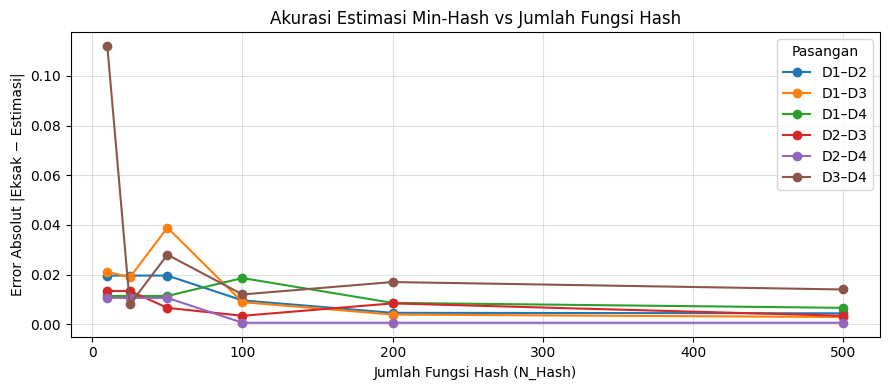

Plot disimpan sebagai minhash_akurasi.png


In [12]:
# ============================================================
# LANGKAH H — Analisis pengaruh N_HASH terhadap akurasi estimasi
# ============================================================
n_hash_list = [10, 25, 50, 100, 200, 500]

# Ambil satu pasangan dokumen representatif (D1 dan D2)
pasangan_uji = list(itertools.combinations(nama_dokumen[:min(4, len(nama_dokumen))], 2))

print('ANALISIS AKURASI vs JUMLAH FUNGSI HASH')
print('=' * 70)

rows_analisis = []
for n in n_hash_list:
    random.seed(42)
    params_n = [
        (random.randint(1, PRIME - 1), random.randint(0, PRIME - 1))
        for _ in range(n)
    ]
    sigs_n = {
        dok: minhash_signature(shingle_indices_per_dok[dok], params_n, PRIME)
        for dok in nama_dokumen
    }
    for di, dj in pasangan_uji:
        eksak = matrix_jaccard_eksak.loc[di, dj]
        estimasi = estimasi_jaccard_minhash(sigs_n[di], sigs_n[dj])
        rows_analisis.append({
            'N_Hash': n,
            'Pasangan': f'{di}–{dj}',
            'Jaccard Eksak': round(float(eksak), 4),
            'Estimasi': round(estimasi, 4),
            'Error': round(abs(float(eksak) - estimasi), 4)
        })

df_analisis = pd.DataFrame(rows_analisis)
display(df_analisis)

# Plot error vs N_HASH
fig, ax = plt.subplots(figsize=(9, 4))
for pasangan in df_analisis['Pasangan'].unique():
    subset = df_analisis[df_analisis['Pasangan'] == pasangan]
    ax.plot(subset['N_Hash'], subset['Error'], marker='o', label=pasangan)

ax.set_xlabel('Jumlah Fungsi Hash (N_Hash)')
ax.set_ylabel('Error Absolut |Eksak − Estimasi|')
ax.set_title('Akurasi Estimasi Min-Hash vs Jumlah Fungsi Hash')
ax.legend(title='Pasangan', loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('minhash_akurasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai minhash_akurasi.png')

In [13]:
# ============================================================
# LANGKAH I — Ringkasan & Kesimpulan
# ============================================================
print('=' * 70)
print('RINGKASAN IMPLEMENTASI MIN-HASH')
print('=' * 70)
print(f'Dokumen     : {len(nama_dokumen)} paragraf jurnal')
print(f'K-Shingle   : {K_SHINGLE} (bigram token)')
print(f'Universe    : {len(universe)} shingle unik')
print(f'N_Hash      : {N_HASH} fungsi hash')
print(f'LSH Config  : B={B} band × R={R} baris/band')
print(f'Threshold   : {threshold_lsh:.4f}')
print()

# Tampilkan top pasangan paling mirip
print('TOP 5 PASANGAN PARAGRAF PALING MIRIP (berdasarkan Jaccard Eksak):')
print('-' * 70)
rows_top = []
for di, dj in itertools.combinations(nama_dokumen, 2):
    eksak = float(matrix_jaccard_eksak.loc[di, dj])
    estimasi = float(matrix_minhash.loc[di, dj])
    rows_top.append({
        'Pasangan': f'{di} – {dj}',
        'Jaccard Eksak': round(eksak, 4),
        'Min-Hash Estimasi': round(estimasi, 4),
        'Error': round(abs(eksak - estimasi), 4)
    })

df_top = pd.DataFrame(rows_top).sort_values('Jaccard Eksak', ascending=False).head(5)
display(df_top.reset_index(drop=True))

print()
print('KESIMPULAN:')
mean_error = df_perbandingan['Error Absolut'].mean()
print(f'• Rata-rata error estimasi Min-Hash: {mean_error:.4f}')
print(f'• Makin besar N_Hash → makin kecil error (lihat Langkah H)')
print(f'• LSH menemukan {len(kandidat_mirip)} kandidat pasangan mirip')
print(f'  di atas threshold {threshold_lsh:.4f}')

RINGKASAN IMPLEMENTASI MIN-HASH
Dokumen     : 26 paragraf jurnal
K-Shingle   : 2 (bigram token)
Universe    : 885 shingle unik
N_Hash      : 100 fungsi hash
LSH Config  : B=10 band × R=10 baris/band
Threshold   : 0.7943

TOP 5 PASANGAN PARAGRAF PALING MIRIP (berdasarkan Jaccard Eksak):
----------------------------------------------------------------------


,Pasangan,Jaccard Eksak,Min-Hash Estimasi,Error
0,D19 – D20,0.2619,0.31,0.0481
1,D25 – D26,0.2143,0.21,0.0043
2,D4 – D25,0.1154,0.09,0.0254
3,D4 – D24,0.1059,0.14,0.0341
4,D4 – D26,0.0980,0.09,0.0080



KESIMPULAN:
• Rata-rata error estimasi Min-Hash: 0.0044
• Makin besar N_Hash → makin kecil error (lihat Langkah H)
• LSH menemukan 0 kandidat pasangan mirip
  di atas threshold 0.7943
